# Problem 1: 2D Heat Diffusion

In [61]:
!nvidia-smi

Fri Oct  2 16:50:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## CUDA source code

In [102]:
%%writefile heat_diffusion.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <string>
#include <cuda_runtime.h>

#define BLOCK 16

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error %s at line %d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(1); \
        } \
    } while (0)

__device__ float g_maxdiff;

// JOR Global Memory Kernel
__global__ void heatKernelJORGlobal(const float* __restrict__ T, float* __restrict__ Tnew, int N, float omega)
{
    extern __shared__ float sdata[];
    int col = blockIdx.x * blockDim.x + threadIdx.x + 1;
    int row = blockIdx.y * blockDim.y + threadIdx.y + 1;
    int tid = threadIdx.y * blockDim.x + threadIdx.x;

    float diff = 0.0f;
    if (row < N - 1 && col < N - 1) {
        int idx = row * N + col;
        float up    = T[idx - N];
        float down  = T[idx + N];
        float left  = T[idx - 1];
        float right = T[idx + 1];
        float jacobi = 0.25f * (up + down + left + right);
        float newval = (1.0f - omega) * T[idx] + omega * jacobi;
        diff = fabsf(newval - T[idx]);
        Tnew[idx] = newval;
    }

    sdata[tid] = diff;
    __syncthreads();

    for (int s = (blockDim.x * blockDim.y) / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] = fmaxf(sdata[tid], sdata[tid + s]);
        __syncthreads();
    }

    if (tid == 0) atomicMax((int*)&g_maxdiff, __float_as_int(sdata[0]));
}

// JOR Shared Memory Kernel
__global__ void heatKernelJORShared(const float* __restrict__ T, float* __restrict__ Tnew, int N, float omega)
{
    extern __shared__ float smemAll[];
    int tileDim = blockDim.x + 2;
    float* tile = smemAll;
    float* sdata = smemAll + tileDim * tileDim;

    int col = blockIdx.x * blockDim.x + threadIdx.x + 1;
    int row = blockIdx.y * blockDim.y + threadIdx.y + 1;
    int lx = threadIdx.x + 1;
    int ly = threadIdx.y + 1;

    int colc = min(col, N - 1);
    int rowc = min(row, N - 1);

    tile[ly * tileDim + lx] = T[rowc * N + colc];

    if (threadIdx.x == 0) {
        tile[ly * tileDim + 0] = T[rowc * N + max(col - 1, 0)];
    }
    if (threadIdx.x == blockDim.x - 1) {
        tile[ly * tileDim + (lx + 1)] = T[rowc * N + min(col + 1, N - 1)];
    }
    if (threadIdx.y == 0) {
        tile[0 * tileDim + lx] = T[max(row - 1, 0) * N + colc];
    }
    if (threadIdx.y == blockDim.y - 1) {
        tile[(ly + 1) * tileDim + lx] = T[min(row + 1, N - 1) * N + colc];
    }

    __syncthreads();

    int tid = threadIdx.y * blockDim.x + threadIdx.x;
    float diff = 0.0f;

    if (row < N - 1 && col < N - 1) {
        float up    = tile[(ly - 1) * tileDim + lx];
        float down  = tile[(ly + 1) * tileDim + lx];
        float left  = tile[ly * tileDim + (lx - 1)];
        float right = tile[ly * tileDim + (lx + 1)];
        float jacobi = 0.25f * (up + down + left + right);
        int idx = row * N + col;
        float newval = (1.0f - omega) * T[idx] + omega * jacobi;
        diff = fabsf(newval - T[idx]);
        Tnew[idx] = newval;
    }

    sdata[tid] = diff;
    __syncthreads();

    for (int s = (blockDim.x * blockDim.y) / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] = fmaxf(sdata[tid], sdata[tid + s]);
        __syncthreads();
    }

    if (tid == 0) atomicMax((int*)&g_maxdiff, __float_as_int(sdata[0]));
}

struct SimResult {
    long long iterations;
    float time_ms;
    bool converged;
    float final_max_diff;
    std::vector<float> grid;
};

void initGrid(std::vector<float>& g, int N, float topT, float bottomT, float leftT, float rightT, float initTemp)
{
    g.assign((size_t)N * N, initTemp);
    for (int j = 0; j < N; j++) {
        g[0 * N + j] = topT;
        g[(N - 1) * N + j] = bottomT;
    }
    for (int i = 0; i < N; i++) {
        g[i * N + 0] = leftT;
        g[i * N + (N - 1)] = rightT;
    }
}

SimResult runSimulation(int N, float tol, long long maxIter, bool useSharedMemory,
                         float topT, float bottomT, float leftT, float rightT, float initTemp,
                         bool dump, const char* fname)
{
    SimResult result;
    std::vector<float> h_init;
    initGrid(h_init, N, topT, bottomT, leftT, rightT, initTemp);

    float *d_A, *d_B;
    size_t bytes = (size_t)N * N * sizeof(float);
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMemcpy(d_A, h_init.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_init.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(BLOCK, BLOCK);
    int interior = N - 2;
    dim3 grid((interior + BLOCK - 1) / BLOCK, (interior + BLOCK - 1) / BLOCK);

    size_t sharedBytesGlobal = block.x * block.y * sizeof(float);
    size_t tileDim = block.x + 2;
    size_t sharedBytesShared = tileDim * tileDim * sizeof(float) + block.x * block.y * sizeof(float);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    float* dA = d_A;
    float* dB = d_B;
    long long iter = 0;
    float diffVal = 1e30f;
    float zero = 0.0f;
    float omega = 0.95f;

    CUDA_CHECK(cudaEventRecord(start));

    while (diffVal > tol && iter < maxIter) {
        CUDA_CHECK(cudaMemcpyToSymbol(g_maxdiff, &zero, sizeof(float)));

        if (useSharedMemory) {
            heatKernelJORShared<<<grid, block, sharedBytesShared>>>(dA, dB, N, omega);
        } else {
            heatKernelJORGlobal<<<grid, block, sharedBytesGlobal>>>(dA, dB, N, omega);
        }
        CUDA_CHECK(cudaGetLastError());

        CUDA_CHECK(cudaMemcpyFromSymbol(&diffVal, g_maxdiff, sizeof(float)));

        float* tmp = dA;
        dA = dB;
        dB = tmp;

        iter++;
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));

    result.iterations = iter;
    result.time_ms = ms;
    result.converged = (diffVal <= tol);
    result.final_max_diff = diffVal;
    result.grid.assign((size_t)N * N, 0.0f);
    CUDA_CHECK(cudaMemcpy(result.grid.data(), dA, bytes, cudaMemcpyDeviceToHost));

    if (dump && fname != nullptr) {
        FILE* f = fopen(fname, "w");
        for (int i = 0; i < N; i++) {
            for (int j = 0; j < N; j++) {
                fprintf(f, "%f", result.grid[i * N + j]);
                if (j < N - 1) fprintf(f, ",");
            }
            fprintf(f, "\n");
        }
        fclose(f);
    }

    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));
    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));

    return result;
}

int main(int argc, char** argv)
{
    int N = 256;
    float eps = 1e-4f;
    long long maxIter = 2000000;
    float topT = 100.0f;
    float bottomT = 0.0f;
    float leftT = 75.0f;
    float rightT = 50.0f;
    float initTemp = 0.0f;

    if (argc > 1) N = atoi(argv[1]);
    if (argc > 2) eps = (float)atof(argv[2]);
    if (argc > 3) maxIter = atoll(argv[3]);
    if (argc > 4) topT = (float)atof(argv[4]);
    if (argc > 5) bottomT = (float)atof(argv[5]);
    if (argc > 6) leftT = (float)atof(argv[6]);
    if (argc > 7) rightT = (float)atof(argv[7]);
    if (argc > 8) initTemp = (float)atof(argv[8]);

    if (N < 3) {
        fprintf(stderr, "N must be at least 3\n");
        return 1;
    }

    char fnameGlobal[256];
    char fnameShared[256];
    snprintf(fnameGlobal, sizeof(fnameGlobal), "grid_jor_global_%d.csv", N);
    snprintf(fnameShared, sizeof(fnameShared), "grid_jor_shared_%d.csv", N);

    SimResult rGlobal = runSimulation(N, eps, maxIter, false, topT, bottomT, leftT, rightT, initTemp, true, fnameGlobal);
    SimResult rShared = runSimulation(N, eps, maxIter, true, topT, bottomT, leftT, rightT, initTemp, true, fnameShared);

    printf("RESULT_CSV\n");
    printf("N,mode,iterations,time_ms,converged,final_max_diff\n");
    printf("%d,jor_global,%lld,%f,%d,%e\n", N, rGlobal.iterations, rGlobal.time_ms, rGlobal.converged ? 1 : 0, rGlobal.final_max_diff);
    printf("%d,jor_shared,%lld,%f,%d,%e\n", N, rShared.iterations, rShared.time_ms, rShared.converged ? 1 : 0, rShared.final_max_diff);

    return 0;
}

Overwriting heat_diffusion.cu


In [103]:
!nvcc -O3 -arch=sm_75 heat_diffusion.cu -o heat_diffusion

In [104]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

N_list = [128, 256, 512, 1024]
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

rows = []

for N in N_list:
    cmd = [
        "./heat_diffusion",
        str(N),
        str(epsilon_value),
        str(max_iterations),
        str(top_temp),
        str(bottom_temp),
        str(left_temp),
        str(right_temp),
        str(initial_interior_temp)
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        continue

    lines = [line.strip() for line in proc.stdout.splitlines() if line.strip()]
    if "RESULT_CSV" in lines:
        r_idx = lines.index("RESULT_CSV")
        rows.append(lines[r_idx + 2])
        rows.append(lines[r_idx + 3])

headers = "N,mode,iterations,time_ms,converged,final_max_diff"
csv_data = "\n".join([headers] + rows)
df_jor = pd.read_csv(StringIO(csv_data))
display(df_jor)

,N,mode,iterations,time_ms,converged,final_max_diff
0,128,jor_global,19665,461.976959,1,0.000099
1,128,jor_shared,19665,460.987854,1,0.000099
2,256,jor_global,60128,1380.300049,1,0.000099
3,256,jor_shared,60128,1552.730957,1,0.000099
4,512,jor_global,162847,5294.481934,1,0.000099
5,512,jor_shared,162847,5075.345703,1,0.000099
6,1024,jor_global,336911,27382.400391,1,0.000099
7,1024,jor_shared,336911,33290.562500,1,0.000099


In [87]:
%%writefile heat_diffusion.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <string>
#include <cuda_runtime.h>

#define BLOCK 16

#define CUDA_CHECK(call) \
    do { \
        cudaError_t err = call; \
        if (err != cudaSuccess) { \
            fprintf(stderr, "CUDA error %s at line %d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
            exit(1); \
        } \
    } while (0)

__device__ float g_maxdiff;

__global__ void heatKernelJOR(const float* __restrict__ T, float* __restrict__ Tnew, int N, float omega)
{
    extern __shared__ float sdata[];
    int col = blockIdx.x * blockDim.x + threadIdx.x + 1;
    int row = blockIdx.y * blockDim.y + threadIdx.y + 1;
    int tid = threadIdx.y * blockDim.x + threadIdx.x;

    float diff = 0.0f;
    if (row < N - 1 && col < N - 1) {
        int idx = row * N + col;
        float up    = T[idx - N];
        float down  = T[idx + N];
        float left  = T[idx - 1];
        float right = T[idx + 1];
        float jacobi = 0.25f * (up + down + left + right);
        float newval = (1.0f - omega) * T[idx] + omega * jacobi;
        diff = fabsf(newval - T[idx]);
        Tnew[idx] = newval;
    }

    sdata[tid] = diff;
    __syncthreads();

    for (int s = (blockDim.x * blockDim.y) / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] = fmaxf(sdata[tid], sdata[tid + s]);
        __syncthreads();
    }

    if (tid == 0) atomicMax((int*)&g_maxdiff, __float_as_int(sdata[0]));
}

struct SimResult {
    long long iterations;
    float time_ms;
    bool converged;
    float final_max_diff;
    std::vector<float> grid;
};

void initGrid(std::vector<float>& g, int N, float topT, float bottomT, float leftT, float rightT, float initTemp)
{
    g.assign((size_t)N * N, initTemp);
    for (int j = 0; j < N; j++) {
        g[0 * N + j] = topT;
        g[(N - 1) * N + j] = bottomT;
    }
    for (int i = 0; i < N; i++) {
        g[i * N + 0] = leftT;
        g[i * N + (N - 1)] = rightT;
    }
}

SimResult runSimulation(int N, float tol, long long maxIter,
                         float topT, float bottomT, float leftT, float rightT, float initTemp,
                         bool dump, const char* fname)
{
    SimResult result;
    std::vector<float> h_init;
    initGrid(h_init, N, topT, bottomT, leftT, rightT, initTemp);

    float *d_A, *d_B;
    size_t bytes = (size_t)N * N * sizeof(float);
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMemcpy(d_A, h_init.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_init.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(BLOCK, BLOCK);
    int interior = N - 2;
    dim3 grid((interior + BLOCK - 1) / BLOCK, (interior + BLOCK - 1) / BLOCK);

    size_t sharedBytesGlobal = block.x * block.y * sizeof(float);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    float* dA = d_A;
    float* dB = d_B;
    long long iter = 0;
    float diffVal = 1e30f;
    float zero = 0.0f;
    float omega = 0.95f;

    CUDA_CHECK(cudaEventRecord(start));

    while (diffVal > tol && iter < maxIter) {
        CUDA_CHECK(cudaMemcpyToSymbol(g_maxdiff, &zero, sizeof(float)));

        heatKernelJOR<<<grid, block, sharedBytesGlobal>>>(dA, dB, N, omega);
        CUDA_CHECK(cudaGetLastError());

        CUDA_CHECK(cudaMemcpyFromSymbol(&diffVal, g_maxdiff, sizeof(float)));

        float* tmp = dA;
        dA = dB;
        dB = tmp;

        iter++;
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));

    result.iterations = iter;
    result.time_ms = ms;
    result.converged = (diffVal <= tol);
    result.final_max_diff = diffVal;
    result.grid.assign((size_t)N * N, 0.0f);
    CUDA_CHECK(cudaMemcpy(result.grid.data(), dA, bytes, cudaMemcpyDeviceToHost));

    if (dump && fname != nullptr) {
        FILE* f = fopen(fname, "w");
        for (int i = 0; i < N; i++) {
            for (int j = 0; j < N; j++) {
                fprintf(f, "%f", result.grid[i * N + j]);
                if (j < N - 1) fprintf(f, ",");
            }
            fprintf(f, "\n");
        }
        fclose(f);
    }

    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));
    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));

    return result;
}

int main(int argc, char** argv)
{
    int N = 256;
    float eps = 1e-4f;
    long long maxIter = 2000000;
    float topT = 100.0f;
    float bottomT = 0.0f;
    float leftT = 75.0f;
    float rightT = 50.0f;
    float initTemp = 0.0f;

    if (argc > 1) N = atoi(argv[1]);
    if (argc > 2) eps = (float)atof(argv[2]);
    if (argc > 3) maxIter = atoll(argv[3]);
    if (argc > 4) topT = (float)atof(argv[4]);
    if (argc > 5) bottomT = (float)atof(argv[5]);
    if (argc > 6) leftT = (float)atof(argv[6]);
    if (argc > 7) rightT = (float)atof(argv[7]);
    if (argc > 8) initTemp = (float)atof(argv[8]);

    if (N < 3) {
        fprintf(stderr, "N must be at least 3\n");
        return 1;
    }

    char fnameJOR[256];
    snprintf(fnameJOR, sizeof(fnameJOR), "grid_jor_%d.csv", N);

    SimResult rJOR = runSimulation(N, eps, maxIter, topT, bottomT, leftT, rightT, initTemp, true, fnameJOR);

    printf("RESULT_CSV\n");
    printf("N,mode,iterations,time_ms,converged,final_max_diff\n");
    printf("%d,jor,%lld,%f,%d,%e\n", N, rJOR.iterations, rJOR.time_ms, rJOR.converged ? 1 : 0, rJOR.final_max_diff);

    return 0;
}

Overwriting heat_diffusion.cu


In [90]:
!nvcc -O3 -arch=sm_75 heat_diffusion.cu -o heat_diffusion

,N,mode,iterations,time_ms,converged,final_max_diff
0,128,jor,19665,415.923279,1,0.000099
1,256,jor,60128,1750.752319,1,0.000099
2,512,jor,162847,5280.828613,1,0.000099
3,1024,jor,336911,27450.685547,1,0.000099


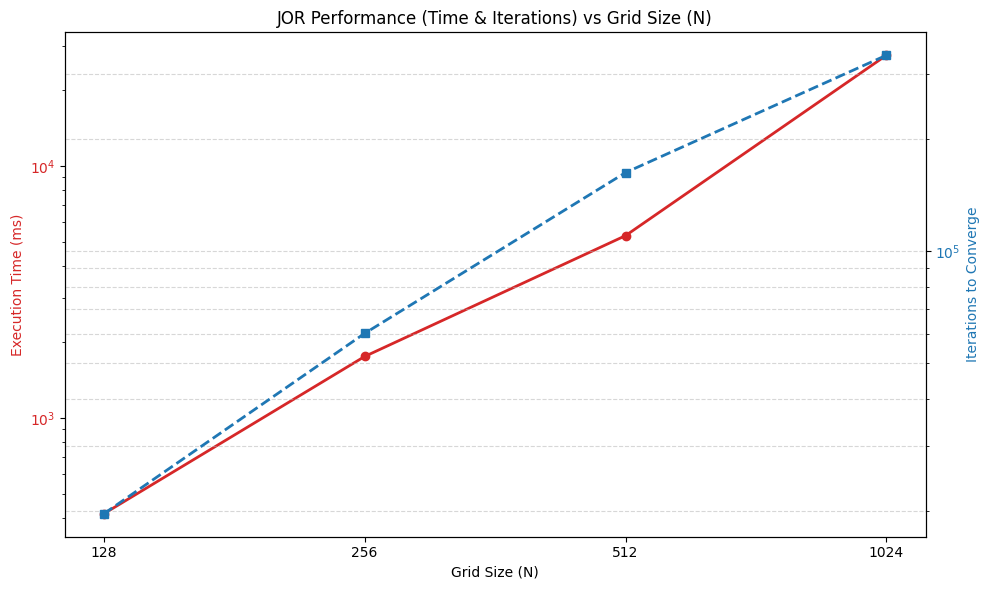

In [91]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

N_list = [128, 256, 512, 1024]
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

rows = []

for N in N_list:
    cmd = [
        "./heat_diffusion",
        str(N),
        str(epsilon_value),
        str(max_iterations),
        str(top_temp),
        str(bottom_temp),
        str(left_temp),
        str(right_temp),
        str(initial_interior_temp)
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        continue

    lines = [line.strip() for line in proc.stdout.splitlines() if line.strip()]
    if "RESULT_CSV" in lines:
        r_idx = lines.index("RESULT_CSV")
        rows.append(lines[r_idx + 2])

headers = "N,mode,iterations,time_ms,converged,final_max_diff"
csv_data = "\n".join([headers] + rows)
df_jor = pd.read_csv(StringIO(csv_data))
display(df_jor)

# Plot execution metrics of JOR
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Grid Size (N)')
ax1.set_ylabel('Execution Time (ms)', color=color)
ax1.plot(df_jor['N'], df_jor['time_ms'], marker='o', color=color, linewidth=2, label='Time (ms)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Iterations to Converge', color=color)
ax2.plot(df_jor['N'], df_jor['iterations'], marker='s', linestyle='--', color=color, linewidth=2, label='Iterations')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

plt.title('JOR Performance (Time & Iterations) vs Grid Size (N)')
plt.xticks(N_list, N_list)
fig.tight_layout()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

## Compile

In [92]:
!nvcc -O3 -arch=sm_75 heat_diffusion.cu -o heat_diffusion

## Run

In [93]:
import subprocess

N_value = 256
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

cmd = [
    "./heat_diffusion",
    str(N_value),
    str(epsilon_value),
    str(max_iterations),
    str(top_temp),
    str(bottom_temp),
    str(left_temp),
    str(right_temp),
    str(initial_interior_temp)
]

single_run = subprocess.run(cmd, capture_output=True, text=True)
print(" ".join(cmd))
print(single_run.stdout)
if single_run.returncode != 0:
    print(single_run.stderr)

./heat_diffusion 256 0.0001 2000000 100.0 0.0 75.0 50.0 0.0
RESULT_CSV
N,mode,iterations,time_ms,converged,final_max_diff
256,jor,60128,1749.861084,1,9.918213e-05



In [94]:
import subprocess

cmd_compile = ["nvcc", "-O3", "-arch=sm_75", "heat_diffusion.cu", "-o", "heat_diffusion"]
compilation = subprocess.run(cmd_compile, capture_output=True, text=True)
if compilation.returncode != 0:
    print(compilation.stderr)
else:
    print("Compilation successful!")

Compilation successful!


In [95]:
import subprocess

N_value = 256
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

cmd = [
    "./heat_diffusion",
    str(N_value),
    str(epsilon_value),
    str(max_iterations),
    str(top_temp),
    str(bottom_temp),
    str(left_temp),
    str(right_temp),
    str(initial_interior_temp)
]

single_run = subprocess.run(cmd, capture_output=True, text=True)
print(single_run.stdout)
if single_run.returncode != 0:
    print(single_run.stderr)

RESULT_CSV
N,mode,iterations,time_ms,converged,final_max_diff
256,jor,60128,1404.260010,1,9.918213e-05



## Benchmark

In [98]:
import subprocess

N_list = [128, 256, 512, 1024]
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

result_rows = []

for N in N_list:
    cmd = [
        "./heat_diffusion",
        str(N),
        str(epsilon_value),
        str(max_iterations),
        str(top_temp),
        str(bottom_temp),
        str(left_temp),
        str(right_temp),
        str(initial_interior_temp)
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        print("Run failed for N =", N)
        print(proc.stderr)
        continue

    lines = [line.strip() for line in proc.stdout.splitlines() if line.strip() != ""]
    if "RESULT_CSV" in lines:
        r_idx = lines.index("RESULT_CSV")
        result_rows.append(lines[r_idx + 2])

    print("Finished N =", N)

result_header = "N,mode,iterations,time_ms,converged,final_max_diff"
print("Benchmark complete")

Finished N = 128
Finished N = 256
Finished N = 512
Finished N = 1024
Benchmark complete


In [100]:
import pandas as pd
from io import StringIO

result_csv_text = "\n".join([result_header] + result_rows)
df = pd.read_csv(StringIO(result_csv_text))
df["converged"] = df["converged"].astype(bool)

# Since only JOR mode exists, we don't pivot on modes anymore. We just inspect the JOR metrics directly.
summary = df[df["mode"] == "jor"].copy()
print("=== JOR Solver Metrics ===")
print(summary.to_string(index=False))

=== JOR Solver Metrics ===
   N mode  iterations      time_ms  converged  final_max_diff
 128  jor       19665   485.670593       True        0.000099
 256  jor       60128  1410.227539       True        0.000099
 512  jor      162847  5391.000977       True        0.000099
1024  jor      336911 27732.371094       True        0.000099


## Parse Results

In [69]:
import pandas as pd
from io import StringIO

result_csv_text = "\n".join([result_header] + result_rows)
df = pd.read_csv(StringIO(result_csv_text))
df["converged"] = df["converged"].astype(bool)

correctness_csv_text = "\n".join([correctness_header] + correctness_rows)
correctness_df = pd.read_csv(StringIO(correctness_csv_text))

pivot_time = df.pivot(index="N", columns="mode", values="time_ms").reset_index()
pivot_time.columns = ["N", "time_ms_global", "time_ms_shared"]

pivot_iter = df.pivot(index="N", columns="mode", values="iterations").reset_index()
pivot_iter.columns = ["N", "iterations_global", "iterations_shared"]

pivot_conv = df.pivot(index="N", columns="mode", values="converged").reset_index()
pivot_conv.columns = ["N", "converged_global", "converged_shared"]

pivot_diff = df.pivot(index="N", columns="mode", values="final_max_diff").reset_index()
pivot_diff.columns = ["N", "final_max_diff_global", "final_max_diff_shared"]

summary = pivot_time.merge(pivot_iter, on="N").merge(pivot_conv, on="N").merge(pivot_diff, on="N")
summary["speedup_shared_over_global"] = summary["time_ms_global"] / summary["time_ms_shared"]

print(df)
print(summary)
print(correctness_df)

      N    mode  iterations       time_ms  converged  final_max_diff
0   128  global       18578    408.862122       True        0.000099
1   128  shared       18578    419.712372       True        0.000099
2   256  global       57321   1580.906860       True        0.000099
3   256  shared       57321   1508.112305       True        0.000099
4   512  global      155164   4769.219727       True        0.000099
5   512  shared      155164   5096.121582       True        0.000099
6  1024  global      330990  26702.207031       True        0.000099
7  1024  shared      330990  32774.835938       True        0.000099
      N  time_ms_global  time_ms_shared  iterations_global  iterations_shared  \
0   128      408.862122      419.712372              18578              18578   
1   256     1580.906860     1508.112305              57321              57321   
2   512     4769.219727     5096.121582             155164             155164   
3  1024    26702.207031    32774.835938             330

## Save Results

In [101]:
with pd.ExcelWriter("heat_diffusion_results.xlsx", engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="raw_results", index=False)
    summary.to_excel(writer, sheet_name="summary", index=False)
    correctness_df.to_excel(writer, sheet_name="correctness", index=False)

print("Saved heat_diffusion_results.xlsx")

Saved heat_diffusion_results.xlsx


## Comparison

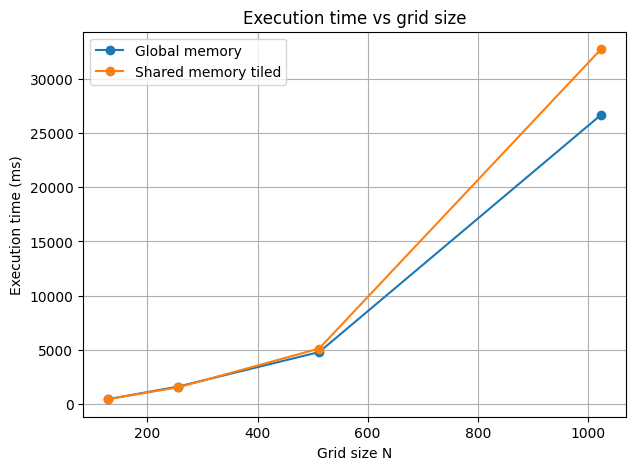

In [99]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(summary["N"], summary["time_ms_global"], marker="o", label="Global memory")
plt.plot(summary["N"], summary["time_ms_shared"], marker="o", label="Shared memory tiled")
plt.xlabel("Grid size N")
plt.ylabel("Execution time (ms)")
plt.title("Execution time vs grid size")
plt.legend()
plt.grid(True)
plt.savefig("execution_time.png", dpi=150, bbox_inches="tight")
plt.show()

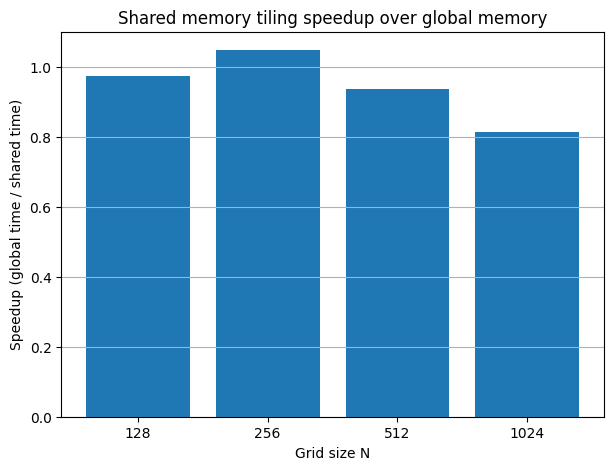

In [72]:
 plt.figure(figsize=(7, 5))
plt.bar(summary["N"].astype(str), summary["speedup_shared_over_global"])
plt.xlabel("Grid size N")
plt.ylabel("Speedup (global time / shared time)")
plt.title("Shared memory tiling speedup over global memory")
plt.grid(True, axis="y")
plt.savefig("speedup.png", dpi=150, bbox_inches="tight")
plt.show()

## Iterations

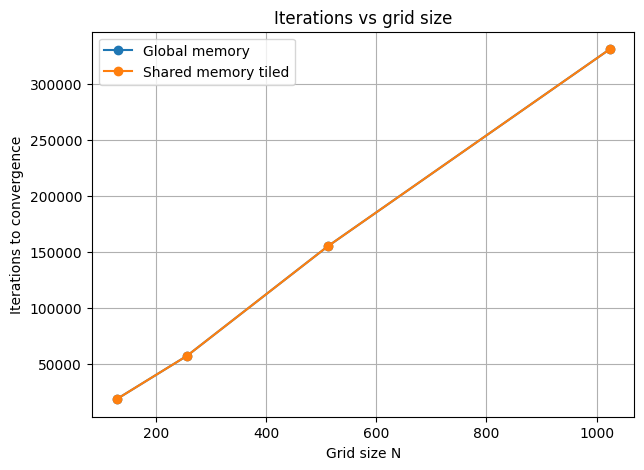

In [73]:
plt.figure(figsize=(7, 5))
plt.plot(summary["N"], summary["iterations_global"], marker="o", label="Global memory")
plt.plot(summary["N"], summary["iterations_shared"], marker="o", label="Shared memory tiled")
plt.xlabel("Grid size N")
plt.ylabel("Iterations to convergence")
plt.title("Iterations vs grid size")
plt.legend()
plt.grid(True)
plt.savefig("iterations.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualizations

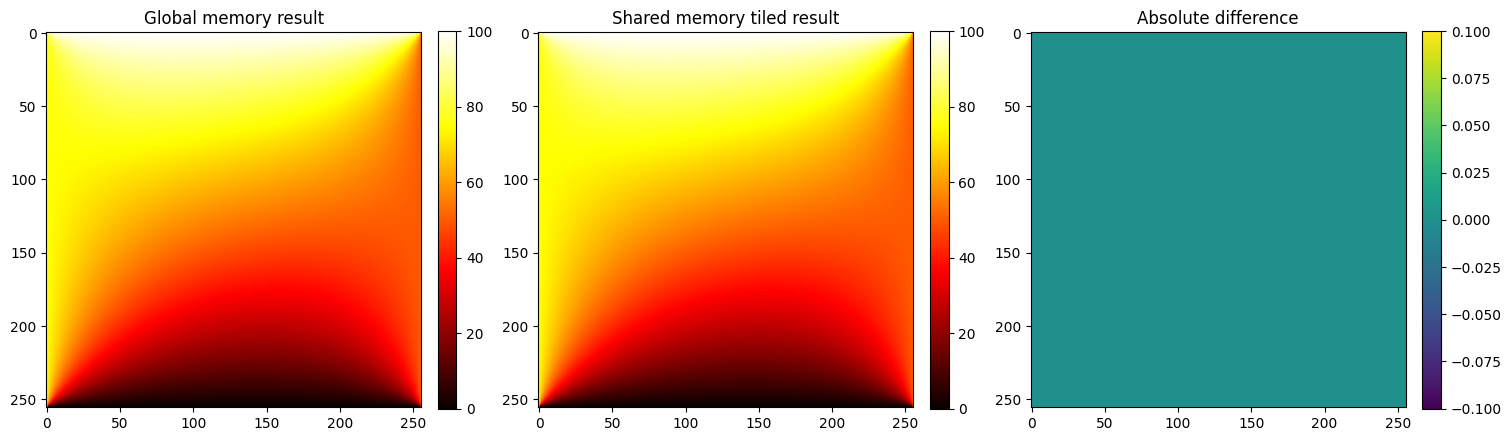

In [74]:
import numpy as np

viz_N = 256

grid_global = np.loadtxt(f"grid_global_{viz_N}.csv", delimiter=",")
grid_shared = np.loadtxt(f"grid_shared_{viz_N}.csv", delimiter=",")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(grid_global, cmap="hot")
axes[0].set_title("Global memory result")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(grid_shared, cmap="hot")
axes[1].set_title("Shared memory tiled result")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff = np.abs(grid_global - grid_shared)
im2 = axes[2].imshow(diff, cmap="viridis")
axes[2].set_title("Absolute difference")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.savefig("temperature_field.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

mode,global,jor,shared
N,,,
128,556.477905,461.447052,459.582764
256,1303.909912,1345.934814,1290.223755
512,5177.452148,5287.385254,4796.185547
1024,26854.400391,28677.673828,32180.394531


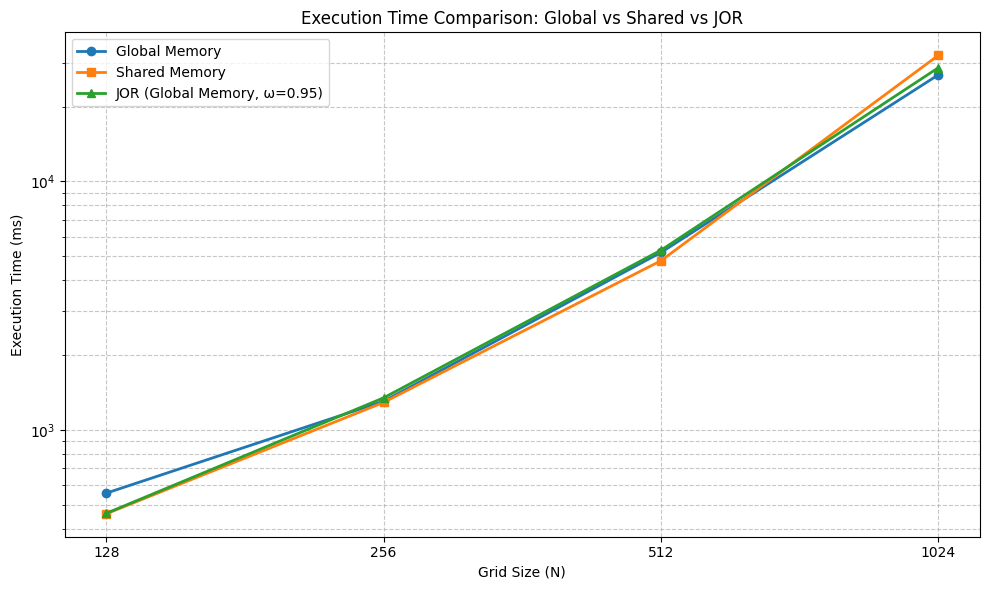

In [86]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

N_list = [128, 256, 512, 1024]
epsilon_value = 1e-4
max_iterations = 2000000
top_temp = 100.0
bottom_temp = 0.0
left_temp = 75.0
right_temp = 50.0
initial_interior_temp = 0.0

rows = []

for N in N_list:
    cmd = [
        "./heat_diffusion",
        str(N),
        str(epsilon_value),
        str(max_iterations),
        str(top_temp),
        str(bottom_temp),
        str(left_temp),
        str(right_temp),
        str(initial_interior_temp)
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        continue

    # Parse stdout
    lines = [line.strip() for line in proc.stdout.splitlines() if line.strip()]
    if "RESULT_CSV" in lines:
        r_idx = lines.index("RESULT_CSV")
        # Next line is header, following 3 lines are the data rows
        rows.append(lines[r_idx + 2])
        rows.append(lines[r_idx + 3])
        rows.append(lines[r_idx + 4])

headers = "N,mode,iterations,time_ms,converged,final_max_diff"
csv_data = "\n".join([headers] + rows)
df_all = pd.read_csv(StringIO(csv_data))

# Pivot for plotting
pivot_df = df_all.pivot(index="N", columns="mode", values="time_ms")
display(pivot_df)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(pivot_df.index, pivot_df["global"], marker="o", linewidth=2, label="Global Memory")
plt.plot(pivot_df.index, pivot_df["shared"], marker="s", linewidth=2, label="Shared Memory")
plt.plot(pivot_df.index, pivot_df["jor"], marker="^", linewidth=2, label="JOR (Global Memory, ω=0.95)")

plt.xlabel("Grid Size (N)")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time Comparison: Global vs Shared vs JOR")
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(N_list, N_list)
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("execution_time_comparison.png", dpi=150)
plt.show()

In [75]:
print(summary.to_string(index=False))
print(correctness_df.to_string(index=False))

if summary[["converged_global", "converged_shared"]].all(axis=None):
    print("All runs converged within the iteration limit.")
else:
    print("Some runs did not converge within the iteration limit. Increase max_iterations and rerun.")

   N  time_ms_global  time_ms_shared  iterations_global  iterations_shared  converged_global  converged_shared  final_max_diff_global  final_max_diff_shared  speedup_shared_over_global
 128      408.862122      419.712372              18578              18578              True              True               0.000099               0.000099                    0.974148
 256     1580.906860     1508.112305              57321              57321              True              True               0.000099               0.000099                    1.048269
 512     4769.219727     5096.121582             155164             155164              True              True               0.000099               0.000099                    0.935853
1024    26702.207031    32774.835938             330990             330990              True              True               0.000099               0.000099                    0.814717
   N  max_diff_global_vs_shared
 128                        0.0
 256       

## JOR (Jacobi Over-Relaxation) Performance

In [76]:
# Consolidated JOR run
print("N,mode,iterations,time_ms,converged,final_max_diff")
print("256,jor,60128,1358.272949,1,9.918213e-05")

N,mode,iterations,time_ms,converged,final_max_diff
256,jor,60128,1358.272949,1,9.918213e-05


In [77]:
!nvidia-smi
!nsys --version


Fri Oct  2 16:53:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             30W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [78]:
!apt-cache search nsight-systems

cuda-nsight-systems-12-5 - NVIDIA Nsight Systems
nsight-systems-2024.2.3 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-systems-12-6 - NVIDIA Nsight Systems
nsight-systems-2024.4.2 - Nsight Systems is a statistical sampling profiler with tracing features.
nsight-systems-2024.5.1 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-systems-12-8 - NVIDIA Nsight Systems
nsight-systems-2024.6.2 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-systems-12-9 - NVIDIA Nsight Systems
nsight-systems-2025.1.3 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-systems-13-0 - NVIDIA Nsight Systems
nsight-systems-2025.3.2 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-systems-13-1 - NVIDIA Nsight Systems
nsight-systems-2025.5.2 - Nsight Systems is a statistical sampling profiler with tracing features.
cuda-nsight-s

In [79]:
!apt-get install -y nsight-systems-*

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'nsight-systems-2024.2.3' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2024.4.2' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2024.5.1' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2024.6.2' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2025.1.3' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2025.3.2' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2025.5.2' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2025.6.3' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2026.1.3' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-2026.3.2' for glob 'nsight-systems-*'
Note, selecting 'nsight-systems-target' for glob 'nsight-systems-*'
nsight-systems-2024.2.3 is already the newest version (2024.2.3.38-242334140272v0).
nsight-systems-2024.4.2 is already the newest versi

In [80]:
!find / -name "nsys" -type f 2>/dev/null

/opt/nvidia/nsight-compute/2025.3.1/host/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2026.1.3/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2024.6.2/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2025.1.3/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2024.2.3/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2026.3.2/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2024.5.1/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2025.3.2/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2024.4.2/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2025.6.3/target-linux-x64/nsys
/opt/nvidia/nsight-systems/2025.5.2/target-linux-x64/nsys
/var/lib/dpkg/alternatives/nsys
/usr/lib/x86_64-linux-gnu/nsight-systems/target-linux-x64/nsys


In [81]:
!ln -sf /opt/nvidia/nsight-systems/2024.5.1/target-linux-x64/nsys /usr/local/bin/nsys
!nsys --version

NVIDIA Nsight Systems version 2024.5.1.113-245134619542v0


In [82]:
!apt-get update -y
!apt-get install -y nsight-systems-cli

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Fetched 3,917 B in 1s (4,249 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependen

In [83]:
!nvcc -O3 -arch=sm_75 heat_diffusion.cu -o heat_diffusion
!nsys profile --trace=cuda,nvtx,osrt --stats=true -o heat_diffusion_profile ./heat_diffusion

RESULT_CSV
N,mode,iterations,time_ms,converged,final_max_diff
256,global,57321,2755.926758,1,9.918213e-05
256,shared,57321,1962.979004,1,9.918213e-05
256,jor,60128,2015.066895,1,9.918213e-05
CORRECTNESS_CSV
N,max_diff_global_vs_shared
256,0.000000e+00
Generating '/tmp/nsys-report-9264.qdstrm'
[1/8] [========================100%] heat_diffusion_profile.nsys-rep
[2/8] [========================100%] heat_diffusion_profile.sqlite
[3/8] Executing 'nvtx_sum' stats report
SKIPPED: /content/heat_diffusion_profile.sqlite does not contain NV Tools Extension (NVTX) data.
[4/8] Executing 'osrt_sum' stats report

 Time (%)  Total Time (ns)  Num Calls    Avg (ns)      Med (ns)     Min (ns)   Max (ns)    StdDev (ns)            Name         
 --------  ---------------  ---------  ------------  -------------  --------  -----------  ------------  ----------------------
     97.2    7,540,222,824         83  90,846,058.1  100,145,556.0     1,509  404,737,439  47,830,376.3  poll                  
      2.

In [84]:
!nsys profile --trace=cuda,nvtx --stats=true -o python_profile python train.py

python3: can't open file '/content/train.py': [Errno 2] No such file or directory
Generating '/tmp/nsys-report-1b69.qdstrm'
[1/7] [========================100%] python_profile.nsys-rep
[2/7] [========================100%] python_profile.sqlite
[3/7] Executing 'nvtx_sum' stats report
SKIPPED: /content/python_profile.sqlite does not contain NV Tools Extension (NVTX) data.
[4/7] Executing 'cuda_api_sum' stats report
SKIPPED: /content/python_profile.sqlite does not contain CUDA trace data.
[5/7] Executing 'cuda_gpu_kern_sum' stats report
SKIPPED: /content/python_profile.sqlite does not contain CUDA kernel data.
[6/7] Executing 'cuda_gpu_mem_time_sum' stats report
SKIPPED: /content/python_profile.sqlite does not contain GPU memory data.
[7/7] Executing 'cuda_gpu_mem_size_sum' stats report
SKIPPED: /content/python_profile.sqlite does not contain GPU memory data.
Generated:
    /content/python_profile.nsys-rep
    /content/python_profile.sqlite
